# Transformer for Classifying Time-Series Lightcurves of Celestial Objects
### Student id: C00313459
### Name: Amisha Das

# 1. Introduction

This notebook focuses on using a Transformer-based deep leaning model for classifying lightcurve data. It does so by learning the pattern of an object's brightness vairation over time.

It works with various strategies such as input normalisation, class weighting and feature engineering. At the end a confusion matrix is also used for analysing model accuracy.

[Data source](https://users.flatironinstitute.org/~polymathic/data/MultimodalUniverse/v1/plasticc/data/healpix=2260/)

Note:

This notebook has been edited from the original notebook built by [Alice Martin and adapted to pytorch by Charles Ollion](https://colab.research.google.com/github/charlesollion/dlexperiments/blob/master/7-Transformers-Timeseries/Transformers_for_timeseries.ipynb)


# 2. Transformer model


In [6]:
import torch
import torch.nn as nn

class Transformer(nn.Module):
    def __init__(self, num_layers, D, H, hidden_mlp_dim, inp_features, out_features, dropout_rate):
        super().__init__()
        self.input_projection = nn.Linear(inp_features, D)
        self.transformer_layer = nn.TransformerEncoderLayer(d_model=D, nhead=H, dim_feedforward=hidden_mlp_dim, dropout=dropout_rate)
        self.encoder = nn.TransformerEncoder(self.transformer_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout_rate)
        self.output_layer = nn.Linear(D, out_features)

    def forward(self, x, mask):
        x = self.input_projection(x)
        x = self.encoder(x.transpose(0, 1), mask=mask)
        x = self.dropout(x)
        x = x.mean(dim=0)  # Global average pooling over sequence
        return self.output_layer(x), {}


## 1.2. Load preprocessed data

This data ia already in 'combined_lightcurves_top5.npz'


In [8]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [9]:
data = np.load("combined_lightcurves_top5.npz", allow_pickle=True)
X = data['X']  # (N, 6, 3, 150)
y = data['y']

In [10]:
# Reshape
X = X.transpose(0, 3, 1, 2).reshape(X.shape[0], X.shape[3], -1)  # (N, 150, 18)

Normalising features


In [11]:
N, T, F = X.shape
scaler = StandardScaler()
X = scaler.fit_transform(X.reshape(-1, F)).reshape(N, T, F)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [12]:
import torch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

# 3. Training the model

In [13]:
from sklearn.utils.class_weight import compute_class_weight


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [15]:
transformer = Transformer(
    num_layers=3,
    D=128,
    H=4,
    hidden_mlp_dim=256,
    inp_features=18,
    out_features=num_classes,
    dropout_rate=0.2
).to(device)

optimizer = torch.optim.Adam(transformer.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Due to high imbalance of classes and unavailable data, class weights were added to improve model accuracy.

In [16]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

loss_fn = nn.CrossEntropyLoss(weight=class_weights)

num_epochs = 45
losses, val_losses = [], []

In [17]:
def create_mask(seq_len):
    return torch.zeros(seq_len, seq_len).type(torch.bool).to(device)

for epoch in range(num_epochs):
    transformer.train()
    epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        mask = create_mask(x.shape[1])
        logits, _ = transformer(x, mask)
        loss = loss_fn(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))

    # Validation
    transformer.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            mask = create_mask(x.shape[1])
            logits, _ = transformer(x, mask)
            loss = loss_fn(logits, y)
            val_loss += loss.item()
        val_losses.append(val_loss / len(test_loader))
        scheduler.step(val_losses[-1])

    print(f"Epoch {epoch+1} | Train Loss: {losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

Epoch 1 | Train Loss: 1.5993 | Val Loss: 1.5831
Epoch 2 | Train Loss: 1.5391 | Val Loss: 1.5753
Epoch 3 | Train Loss: 1.4810 | Val Loss: 1.3454
Epoch 4 | Train Loss: 1.3753 | Val Loss: 1.3744
Epoch 5 | Train Loss: 1.3209 | Val Loss: 1.1612
Epoch 6 | Train Loss: 1.3033 | Val Loss: 1.1074
Epoch 7 | Train Loss: 1.2297 | Val Loss: 1.0550
Epoch 8 | Train Loss: 1.1694 | Val Loss: 1.1501
Epoch 9 | Train Loss: 1.1464 | Val Loss: 1.1685
Epoch 10 | Train Loss: 1.1353 | Val Loss: 1.0409
Epoch 11 | Train Loss: 1.0776 | Val Loss: 0.9965
Epoch 12 | Train Loss: 1.0647 | Val Loss: 0.9865
Epoch 13 | Train Loss: 1.0246 | Val Loss: 0.8906
Epoch 14 | Train Loss: 0.9827 | Val Loss: 0.9577
Epoch 15 | Train Loss: 0.9588 | Val Loss: 0.9217
Epoch 16 | Train Loss: 0.9422 | Val Loss: 0.9057
Epoch 17 | Train Loss: 0.9231 | Val Loss: 0.7888
Epoch 18 | Train Loss: 0.8945 | Val Loss: 0.9632
Epoch 19 | Train Loss: 0.8927 | Val Loss: 0.8000
Epoch 20 | Train Loss: 0.8651 | Val Loss: 0.7459
Epoch 21 | Train Loss: 0.8317

# 4. Evaluation


In [23]:
from sklearn.metrics import accuracy_score, classification_report
all_preds, all_targets = [], []
transformer.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        mask = create_mask(x.shape[1])
        logits, _ = transformer(x, mask)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

print("\n Accuracy:", accuracy_score(all_targets, all_preds))
print("\n Classification Report:\n", classification_report(all_targets, all_preds))

num_classes = len(np.unique(y_encoded))


 Accuracy: 0.631578947368421

 Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.64      0.66       180
           1       0.12      0.37      0.18        30
           2       0.87      0.87      0.87        23
           3       0.66      0.90      0.76        21
           4       0.80      0.62      0.69       278

    accuracy                           0.63       532
   macro avg       0.62      0.68      0.63       532
weighted avg       0.71      0.63      0.66       532



In [19]:
all_targets = []
all_preds = []

transformer.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        mask = create_mask(x.shape[1])
        logits, _ = transformer(x, mask)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())


### 3.1. Confusion matrix


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

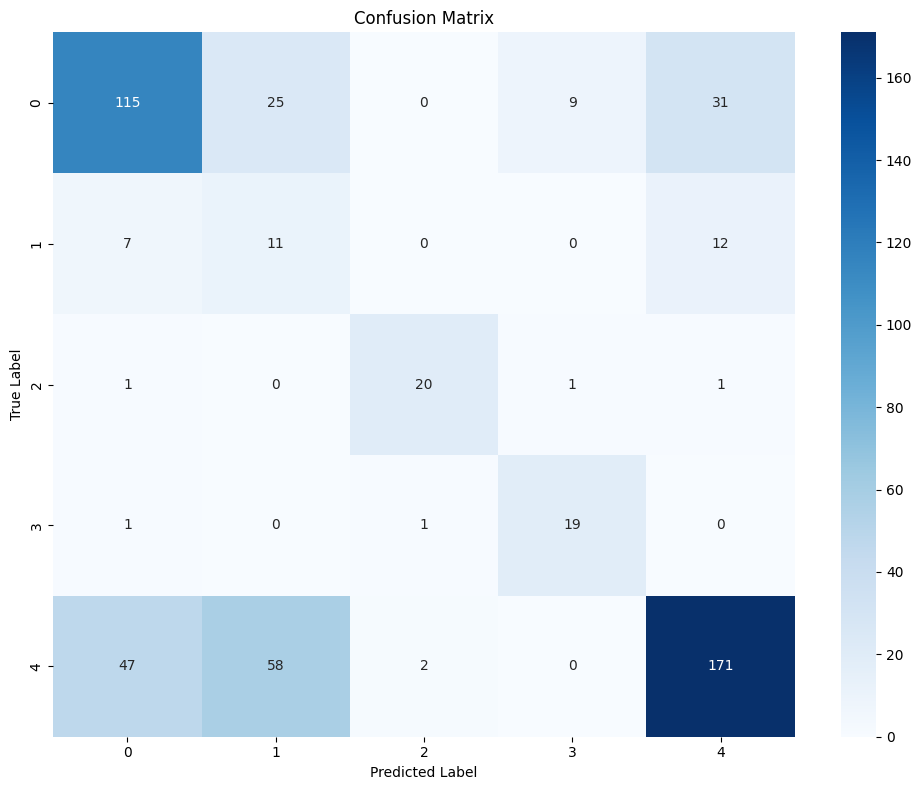

In [24]:
cm = confusion_matrix(all_targets, all_preds)
labels = encoder.classes_  # or use np.unique(all_targets) if encoder is not defined

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(all_targets), yticklabels=np.unique(all_targets))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [21]:
# Save these after model evaluation
all_targets = []  # True labels
all_preds = []    # Predicted labels

transformer.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        mask = create_mask(x.shape[1])
        logits, _ = transformer(x, mask)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())


In [ ]:

from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Per-class sample count
print(" Sample count per class in test set:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

In [ ]:
# Compute precision, recall, F1
precision, recall, f1, support = precision_recall_fscore_support(all_targets, all_preds, labels=np.unique(y_test))


#### 3.2. Bar chart


🔍 Sample count per class in test set:
Class 0: 180
Class 1: 30
Class 2: 23
Class 3: 21
Class 4: 278


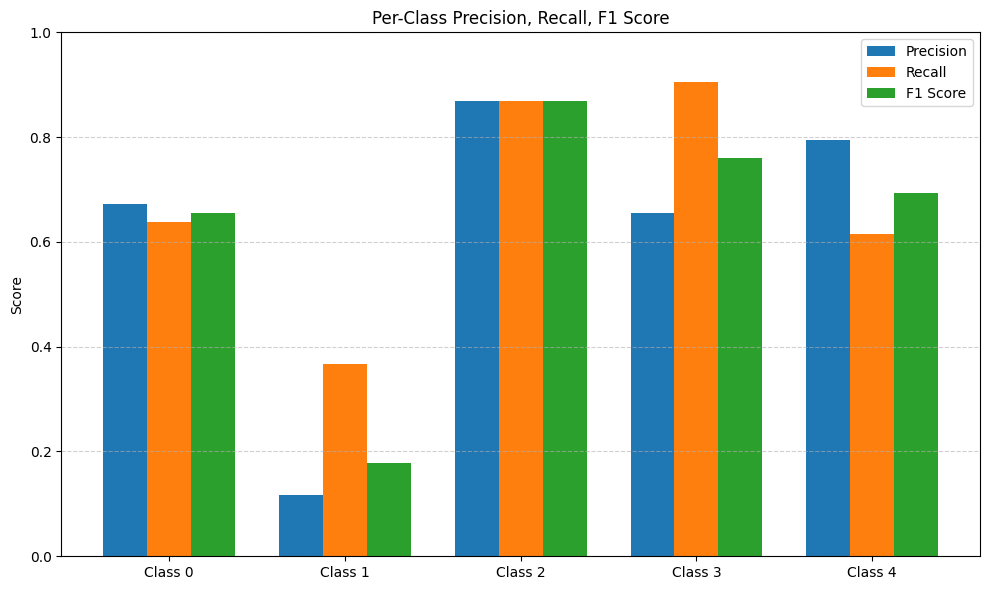

In [22]:
labels = [f"Class {i}" for i in np.unique(y_test)]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, F1 Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 5. Log

In [25]:
import pandas as pd

In [26]:

log = pd.read_excel("final_log.xlsx")
pd.set_option('display.max_colwidth', None)
log


,Section,Description,Level of Difficulty,Time Spent (mins),Change From,Changed To,Old Code,New Code
0,NaN,NaN,making model deeper,20.0,NaN,NaN,"transformer = Transformer(\n num_layers=2,\n D=64,\n H=4,\n hidden_mlp_dim=128,\n inp_features=18,\n out_features=num_classes,\n dropout_rate=0.1\n).to(device)","transformer = Transformer(\n num_layers=3,\n D=128,\n H=4,\n hidden_mlp_dim=256,\n inp_features=18,\n out_features=num_classes,\n dropout_rate=0.2\n).to(device)"
1,NaN,NaN,NaN,45.0,"Basic architecture, no weighting or normalization",Input normalization and CrossEntropyLoss,loss_fn = nn.CrossEntropyLoss(),"scaler = StandardScaler(); X = scaler.fit_transform(X.reshape(-1, F)).reshape(N, T, F)"
2,NaN,Initial Transformer with 18 input features and 5-class classification,Medium,30.0,Uniform loss,Weighted loss based on class frequencies,loss_fn = nn.CrossEntropyLoss(),loss_fn = nn.CrossEntropyLoss(weight=class_weights)
3,Baseline Transformer,Added class weighting to handle imbalance,High,25.0,train_loader = DataLoader(...),"train_loader = DataLoader(..., sampler=WeightedRandomSampler(...))",shuffle=True,"sampler=WeightedRandomSampler(sample_weights, len(sample_weights))"
4,Transformer with Class Weights,Added WeightedRandomSampler to train_loader,High,60.0,"X shape (N, 150, 18)","X shape (N, 150, 42)","X = ... .reshape(N, 150, 18)","X = np.concatenate([X, feats_expanded], axis=-1)"
5,Transformer with Weighted Sampling,Merged original lightcurves with engineered features,High,20.0,num_layers=2,num_layers=4,num_layers=2,num_layers=4
6,Transformer with Feature Engineering,Increased depth to improve accuracy,Medium,25.0,accuracy_score and classification_report only,Added seaborn plots and sample count summaries,print(classification_report(...)),plot_confusion_matrix(...); plot_per_class_metrics(...)
7,Deeper Transformer,Added PR-F1 plots and confusion matrix to evaluate class performance,Medium,NaN,NaN,NaN,NaN,NaN
8,Final Transformer with Analytics,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 6. Conclusion

After a long series of experimentation and refinements, the transformer model achieved signifciant improvement in classification accuracy (from 29% to 63%).

Feature augmentation, class weights and deepening the neural network showed most improvement.

# Appendices, Acknowledgments and References

- Original [Notebook](https://colab.research.google.com/github/charlesollion/dlexperiments/blob/master/7-Transformers-Timeseries/Transformers_for_timeseries.ipynb)
- [Attention is all You Need](https://arxiv.org/abs/1706.03762)
- ChatGPT for debugging and code
- Pytorch [Transformers](https://pytorch.org/hub/huggingface_pytorch-transformers/)
- How to apply standard [scaler](https://stackoverflow.com/questions/69286330/how-to-apply-sklearn-standardscaler-on-3d-numpy-array)
- [Cross Entropy Loss](https://stackoverflow.com/questions/60397812/how-to-set-weights-in-pytorch-crossentropyloss)